# 🔐 Binary entropy files

Run the cells below to create two binary files in the same directory as this notebook:

- `entropy_32mb.bin`: 32,000,000 bytes drawn from the operating system's cryptographically secure random source.
- `sha256_chain_1000000.bin`: 1,000,000 consecutive SHA-256 digests, each written as its raw 32-byte binary value (never as hexadecimal text).

The first digest is `SHA256(seed)`. Each later digest is `SHA256(previous_raw_digest)`. The chain file is therefore exactly 32,000,000 bytes.

In [21]:
from pathlib import Path
import hashlib
import os

OUTPUT_DIRECTORY = Path.cwd()
SEED = 'pippo'
ENTROPY_BYTES = 32_000_000
HASH_COUNT = 1_000_000
CHUNK_SIZE = 1_000_000

entropy_path = OUTPUT_DIRECTORY / 'entropy_32mb.bin'
chain_path = OUTPUT_DIRECTORY / 'sha256_chain_1000000.bin'


In [22]:
# Write cryptographically secure random bytes without keeping the full file in memory.
with entropy_path.open('wb') as output:
    remaining = ENTROPY_BYTES
    while remaining:
        size = min(CHUNK_SIZE, remaining)
        output.write(os.urandom(size))
        remaining -= size

print(f'Wrote {entropy_path} ({entropy_path.stat().st_size:,} bytes)')


Wrote /home/valerio/MyProjects/fair_dice/entropy_32mb.bin (32,000,000 bytes)


In [23]:
# Write raw digest bytes: SHA256(seed), then SHA256(previous digest), repeated.
digest = hashlib.sha256(SEED.encode('utf-8')).digest()

with chain_path.open('wb') as output:
    for _ in range(HASH_COUNT):
        output.write(digest)
        digest = hashlib.sha256(digest).digest()

print(f'Wrote {chain_path} ({chain_path.stat().st_size:,} bytes)')
print(f'Expected size: {HASH_COUNT * hashlib.sha256().digest_size:,} bytes')


Wrote /home/valerio/MyProjects/fair_dice/sha256_chain_1000000.bin (32,000,000 bytes)
Expected size: 32,000,000 bytes


In [24]:
# Confirm both outputs have the intended binary sizes without stopping the notebook.
expected_chain_bytes = HASH_COUNT * hashlib.sha256().digest_size
print(f'Entropy file size: {entropy_path.stat().st_size:,} bytes; expected {ENTROPY_BYTES:,}')
print(f'Hash-chain file size: {chain_path.stat().st_size:,} bytes; expected {expected_chain_bytes:,}')


Entropy file size: 32,000,000 bytes; expected 32,000,000
Hash-chain file size: 32,000,000 bytes; expected 32,000,000


## Entropy analysis of the random file

The following cells examine `entropy_32mb.bin` without treating any result as a proof of randomness. They are useful warning checks: unexpected 256-bit collisions, an extreme imbalance of one-bits, unusual byte frequencies, or a low Shannon estimate would all merit investigation. Passing them does not prove that a source is cryptographically secure.

In [25]:
import math

ANALYSIS_PATH = entropy_path
HASH_CHUNK_BYTES = 32  # 256 bits

if not ANALYSIS_PATH.exists():
    print(f'File not found: {ANALYSIS_PATH}. Run the file-generation cells first.')
else:
    file_size = ANALYSIS_PATH.stat().st_size
    full_chunks, trailing_bytes = divmod(file_size, HASH_CHUNK_BYTES)
    print(f'Analysing: {ANALYSIS_PATH}')
    print(f'Full 256-bit chunks: {full_chunks:,}; trailing bytes ignored: {trailing_bytes}')


Analysing: /home/valerio/MyProjects/fair_dice/entropy_32mb.bin
Full 256-bit chunks: 1,000,000; trailing bytes ignored: 0


In [26]:
# Stream the file once: count bytes and one-bits, and look for duplicate 256-bit chunks.
byte_counts = [0] * 256
bit_ones = 0
total_bytes = 0
generated = set()
collision_count = 0

if ANALYSIS_PATH.exists():
    with ANALYSIS_PATH.open('rb') as input_file:
        while chunk := input_file.read(HASH_CHUNK_BYTES):
            if len(chunk) != HASH_CHUNK_BYTES:
                print(f'Ignored final partial chunk of {len(chunk)} bytes.')
                break
            if chunk in generated:
                collision_count += 1
            else:
                generated.add(chunk)
            for byte in chunk:
                byte_counts[byte] += 1
                bit_ones += byte.bit_count()
            total_bytes += len(chunk)

    print(f'0) 256-bit collision check: {collision_count:,} duplicate chunks among {total_bytes // HASH_CHUNK_BYTES:,}.')
    print('   Guide: a 32 MB random file has 1,000,000 chunks; any duplicate 256-bit chunk is extraordinarily unlikely and should be investigated.')


0) 256-bit collision check: 0 duplicate chunks among 1,000,000.
   Guide: a 32 MB random file has 1,000,000 chunks; any duplicate 256-bit chunk is extraordinarily unlikely and should be investigated.


In [27]:
if total_bytes:
    total_bits = total_bytes * 8
    expected_ones = total_bits / 2
    std_dev = math.sqrt(total_bits) / 2
    z_score = abs(bit_ones - expected_ones) / std_dev
    print(f'1) Monobit test: {bit_ones:,} ones and {total_bits - bit_ones:,} zeros; z-score = {z_score:.3f}.')
    print('   Guide: 0 means an exact half/half split. A z-score below 4 is a typical non-alarm threshold; 4 or more is an unusually large imbalance.')
else:
    print('No complete data was available for the monobit test.')


1) Monobit test: 128,003,610 ones and 127,996,390 zeros; z-score = 0.451.
   Guide: 0 means an exact half/half split. A z-score below 4 is a typical non-alarm threshold; 4 or more is an unusually large imbalance.


In [28]:
if total_bytes:
    expected_count = total_bytes / 256
    chi_squared = sum((count - expected_count) ** 2 / expected_count for count in byte_counts)
    print(f'2) Byte-frequency chi-squared: {chi_squared:.3f} (255 degrees of freedom).')
    print('   Guide: values roughly between 190 and 330 are a practical central range here. Values outside it are not proof of a problem, but are worth repeating or investigating.')
else:
    print('No complete data was available for the chi-squared test.')


2) Byte-frequency chi-squared: 255.197 (255 degrees of freedom).
   Guide: values roughly between 190 and 330 are a practical central range here. Values outside it are not proof of a problem, but are worth repeating or investigating.


In [29]:
if total_bytes:
    shannon_entropy = -sum(
        (count / total_bytes) * math.log2(count / total_bytes)
        for count in byte_counts if count
    )
    print(f'3) Shannon entropy: {shannon_entropy:.6f} bits per byte.')
    print('   Guide: the maximum is 8.0 bits/byte. For a file this size from a good random source, a value above 7.99 is expected; lower values indicate less-uniform byte frequencies.')
else:
    print('No complete data was available for the Shannon entropy estimate.')


3) Shannon entropy: 7.999994 bits per byte.
   Guide: the maximum is 8.0 bits/byte. For a file this size from a good random source, a value above 7.99 is expected; lower values indicate less-uniform byte frequencies.


## Compare both generated files

This repeats the four checks for both outputs and compares them directly. The SHA-256 chain can look statistically random in these tests even though it is fully deterministic once its seed is known; these tests measure distribution properties, not unpredictability.

In [30]:
def analyse_binary_file(path, chunk_bytes=32):
    """Return collision, monobit, byte-frequency, and Shannon measurements."""
    byte_counts = [0] * 256
    seen_chunks = set()
    collisions = 0
    one_bits = 0
    total_bytes = 0
    trailing_bytes = 0

    with path.open('rb') as input_file:
        while chunk := input_file.read(chunk_bytes):
            if len(chunk) != chunk_bytes:
                trailing_bytes = len(chunk)
                break
            if chunk in seen_chunks:
                collisions += 1
            else:
                seen_chunks.add(chunk)
            for byte in chunk:
                byte_counts[byte] += 1
                one_bits += byte.bit_count()
            total_bytes += len(chunk)

    total_bits = total_bytes * 8
    z_score = abs(one_bits - total_bits / 2) / (math.sqrt(total_bits) / 2)
    expected_byte_count = total_bytes / 256
    chi_squared = sum(
        (count - expected_byte_count) ** 2 / expected_byte_count
        for count in byte_counts
    )
    shannon_entropy = -sum(
        (count / total_bytes) * math.log2(count / total_bytes)
        for count in byte_counts if count
    )
    return {
        'file': path.name,
        'chunks': total_bytes // chunk_bytes,
        'trailing_bytes': trailing_bytes,
        'collisions': collisions,
        'ones': one_bits,
        'zeros': total_bits - one_bits,
        'z_score': z_score,
        'chi_squared': chi_squared,
        'shannon_entropy': shannon_entropy,
    }

comparison_results = []
for path in (entropy_path, chain_path):
    if path.exists():
        result = analyse_binary_file(path)
        comparison_results.append(result)
        print(f"\n{result['file']}")
        print(f"  0) 256-bit collisions: {result['collisions']:,} / {result['chunks']:,} chunks")
        print(f"  1) Monobit: {result['ones']:,} ones, {result['zeros']:,} zeros; z-score {result['z_score']:.3f}")
        print(f"  2) Byte chi-squared: {result['chi_squared']:.3f}")
        print(f"  3) Shannon entropy: {result['shannon_entropy']:.6f} bits/byte")
    else:
        print(f'Skipped missing file: {path}')

print('\nGuide: no collisions, a monobit z-score below 4, chi-squared roughly 190–330, and Shannon entropy above 7.99 are non-alarming results for these file sizes.')



entropy_32mb.bin
  0) 256-bit collisions: 0 / 1,000,000 chunks
  1) Monobit: 128,003,610 ones, 127,996,390 zeros; z-score 0.451
  2) Byte chi-squared: 255.197
  3) Shannon entropy: 7.999994 bits/byte

sha256_chain_1000000.bin
  0) 256-bit collisions: 0 / 1,000,000 chunks
  1) Monobit: 127,994,338 ones, 128,005,662 zeros; z-score 0.708
  2) Byte chi-squared: 246.655
  3) Shannon entropy: 7.999994 bits/byte

Guide: no collisions, a monobit z-score below 4, chi-squared roughly 190–330, and Shannon entropy above 7.99 are non-alarming results for these file sizes.


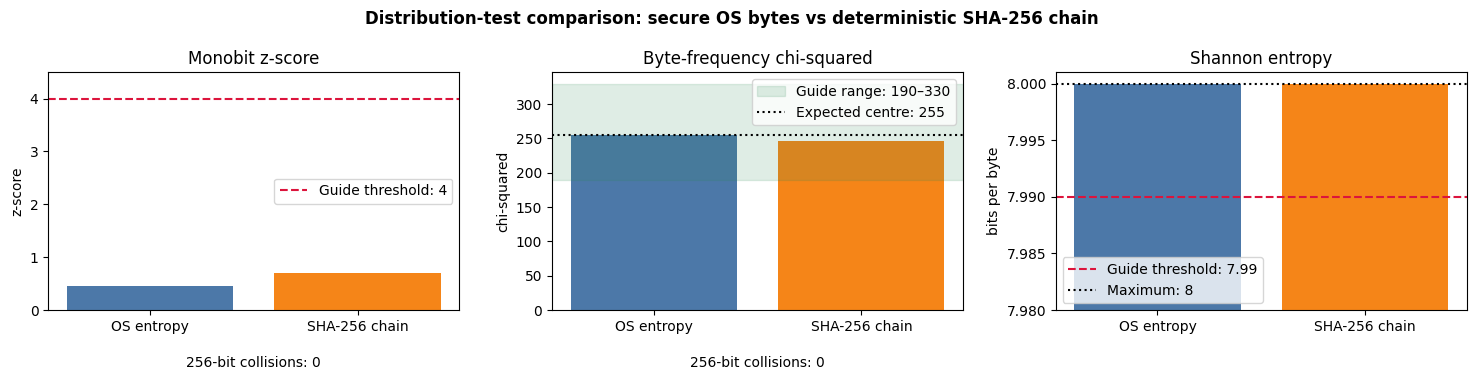

In [31]:
import matplotlib.pyplot as plt

if len(comparison_results) == 2:
    labels = ['OS entropy', 'SHA-256 chain']
    z_scores = [result['z_score'] for result in comparison_results]
    chi_values = [result['chi_squared'] for result in comparison_results]
    shannon_values = [result['shannon_entropy'] for result in comparison_results]
    collisions = [result['collisions'] for result in comparison_results]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    colors = ['#4c78a8', '#f58518']

    axes[0].bar(labels, z_scores, color=colors)
    axes[0].axhline(4, color='crimson', linestyle='--', label='Guide threshold: 4')
    axes[0].set(title='Monobit z-score', ylabel='z-score', ylim=(0, max(4.5, max(z_scores) * 1.2)))
    axes[0].legend()

    axes[1].bar(labels, chi_values, color=colors)
    axes[1].axhspan(190, 330, color='seagreen', alpha=0.15, label='Guide range: 190–330')
    axes[1].axhline(255, color='black', linestyle=':', label='Expected centre: 255')
    axes[1].set(title='Byte-frequency chi-squared', ylabel='chi-squared')
    axes[1].legend()

    axes[2].bar(labels, shannon_values, color=colors)
    axes[2].axhline(7.99, color='crimson', linestyle='--', label='Guide threshold: 7.99')
    axes[2].axhline(8, color='black', linestyle=':', label='Maximum: 8')
    axes[2].set(title='Shannon entropy', ylabel='bits per byte', ylim=(7.98, 8.001))
    axes[2].legend()

    for axis, count in zip(axes, collisions):
        axis.text(0.5, -0.24, f'256-bit collisions: {count:,}', transform=axis.transAxes, ha='center')
    fig.suptitle('Distribution-test comparison: secure OS bytes vs deterministic SHA-256 chain', fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('Generate both binary files before drawing the comparison chart.')
